# 1. Analyse des Betriebsverhaltens einer Kreiselpumpe

In diesem Notebook werden  Messdaten einer industriellen Wasserpumpe ausgewertet. Zunächst werden die theoretischen Herstellerdaten für das verbaute Laufrad (Durchmesser: 269 mm) hinterlegt. Mittels kubischer Interpolation wird das Pumpenkennfeld mathematisch abgebildet, um für jeden gemessenen Volumenstrom die Soll-Förderhöhe und den Pumpenwirkungsgrad zu berechnen.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import interp1d

# ---------------------------------------------------------
# 1. Pumpen-Daten (Basis: Kennlinie für 257 mm Laufrad)
# ---------------------------------------------------------
# Volumenstrom in m³/h
Q_points = np.array([0, 100, 200, 250, 300, 400, 500])

# Förderhöhe in m (abgelesen von der 257-mm-Kurve)
H_points = np.array([23.4, 22.8, 21.5, 19.97, 18.2, 13.5, 8.0])

# Wirkungsgrad (eta) der Pumpe aus dem Diagramm
eta_points = np.array([0.01, 38.0, 65.0, 71.3, 77.0, 82.0, 76.0]) / 100.0

# Interpolations-Funktionen zur stetigen Berechnung
f_H = interp1d(Q_points, H_points, kind='cubic', fill_value='extrapolate')
f_eta = interp1d(Q_points, eta_points, kind='cubic', fill_value='extrapolate')

## 2. Datenaufbereitung
Die Sensordaten werden eingelesen und formatiert. Da industrielle Anlagen im Betrieb  Schwankungen aufweisen, wird zur besseren Visualisierung des operativen Trends zusätzlich ein gleitender Mittelwert berechnet. Dieser dient primär der grafischen Auswertung; die physikalischen Berechnungen basieren weiterhin auf den genauen Daten.

In [27]:
# ---------------------------------------------------------
# 2. Messdaten einlesen & aufbereiten
# ---------------------------------------------------------
filename = '/content/sample_data/volume_flow_data.csv'
df = pd.read_csv(filename)
col_flow = 'Volume Flow (m^3/h)'

# Zeitstempel formatieren
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Förderhöhe und Pumpenwirkungsgrad für jeden Messpunkt berechnen
df['H_m'] = f_H(df[col_flow])
df['eta_pumpe'] = np.clip(f_eta(df[col_flow]), 0.01, 1.0)

# Glättung des Volumenstroms (15-Minuten-Fenster) zur Trendanalyse
df['Q_smoothed'] = df[col_flow].rolling(window=15, min_periods=1).mean()

## Physikalische und wirtschaftliche Berechnung
Die Leistungsberechnung erfolgt folgendermaßen: Ausgehend von der hydraulischen Leistung ($P_{hyd} = \rho \cdot g \cdot Q \cdot H$) wird über den Pumpenwirkungsgrad die Wellenleistung und unter Einbezug des Motorwirkungsgrads (93,6 %) die elektrische Netzleistung berechnet. Die Energiewerte werden für das vorgegebene Messintervall ($\Delta t$ = 1 Minute) integriert und in Nutz- sowie Verlustenergie aufgeschlüsselt. Für die Abschätzung der Betriebskosten wird ein Industriestrompreis von 0,15 €/kWh angesetzt.

In [28]:
# ---------------------------------------------------------
# 3. Physikalische & Wirtschaftliche Berechnungen
# ---------------------------------------------------------
rho = 1000 # Dichte von Wasser (kg/m³)
g = 9.81   # Erdbeschleunigung (m/s²)
eta_motor = 0.936 # Wirkungsgrad Elektromotor (aus Datenblatt)
strom_tarif = 0.15 # Annahme Strompreis in €/kWh

# Leistungsberechnung in kW (mit individuellen Variablen)
df['Power_hyd_kW'] = (rho * g * (df[col_flow] / 3600) * df['H_m']) / 1000
df['Power_shaft_kW'] = df['Power_hyd_kW'] / df['eta_pumpe']
df['Power_grid_kW'] = df['Power_shaft_kW'] / eta_motor

# Energieberechnung in kWh für den Zeitraum (1 Minute = 1/60 h)
delta_time = 1 / 60
df['Energy_hyd_kWh'] = df['Power_hyd_kW'] * delta_time
df['Energy_shaft_kWh'] = df['Power_shaft_kW'] * delta_time
df['Energy_grid_kWh'] = df['Power_grid_kW'] * delta_time

# Verluste isolieren
df['Loss_Pump_kWh'] = df['Energy_shaft_kWh'] - df['Energy_hyd_kWh']
df['Loss_Motor_kWh'] = df['Energy_grid_kWh'] - df['Energy_shaft_kWh']
df['Loss_Total_kWh'] = df['Energy_grid_kWh'] - df['Energy_hyd_kWh']

# Geglättete Werte für saubere Diagramme (Trendlinien)
df['Power_grid_trend'] = df['Power_grid_kW'].rolling(window=15, min_periods=1).mean()
df['Power_hyd_trend'] = df['Power_hyd_kW'].rolling(window=15, min_periods=1).mean()

# Laufende Kosten berechnen und glätten
df['Cost_hyd'] = df['Power_hyd_kW'] * strom_tarif
df['Cost_loss'] = (df['Power_grid_kW'] - df['Power_hyd_kW']) * strom_tarif
df['Cost_hyd_trend'] = df['Cost_hyd'].rolling(window=15, min_periods=1).mean()
df['Cost_loss_trend'] = df['Cost_loss'].rolling(window=15, min_periods=1).mean()

## 4. Ergebnisse
In diesem Abschnitt werden die berechneten Kennzahlen der Pumpenanlage übersichtlich zusammengefasst. Dafür berechnet der Code aus den zeitlich aufgelösten Messdaten zunächst die relevanten Mittelwerte, wie etwa den durchschnittlichen Durchfluss, die Förderhöhe sowie die hydraulischen und elektrischen Leistungen. Darüber hinaus werden die anfallenden Energiewerte über den gesamten Messzeitraum aufsummiert. Dies ermöglicht es, den genauen Stromverbrauch sowie die konkreten Energieverluste von Motor und Pumpe in Kilowattstunden auszuweisen. Abschließend werden diese technischen Daten in eine wirtschaftliche Kennzahl übersetzt, indem die gesamten Betriebskosten sowie der Verlust durch Ineffizienz berechnet werden. Die strukturierte Ausgabe all dieser Ergebnisse erfolgt automatisiert im Anschluss an den Code-Block.

In [29]:
# ---------------------------------------------------------
# 4. Numerische Ausgabe (Individuelles Layout)
# ---------------------------------------------------------
# Zeit und Mittelwerte berechnen
dauer_stunden = len(df) / 60
avg_flow = df[col_flow].mean()
avg_head = df['H_m'].mean()
avg_pwr_hyd = df['Power_hyd_kW'].mean()
avg_pwr_shaft = df['Power_shaft_kW'].mean()
avg_pwr_grid = df['Power_grid_kW'].mean()

# Energiesummen bilden
sum_E_hyd = df['Energy_hyd_kWh'].sum()
sum_E_shaft = df['Energy_shaft_kWh'].sum()
sum_E_grid = df['Energy_grid_kWh'].sum()

sum_loss_pump = df['Loss_Pump_kWh'].sum()
sum_loss_motor = df['Loss_Motor_kWh'].sum()
sum_loss_total = df['Loss_Total_kWh'].sum()

# Wirkungsgrade im Durchschnitt
eff_pump = (sum_E_hyd / sum_E_shaft) * 100
eff_system = (sum_E_hyd / sum_E_grid) * 100

# Wirtschaftlichkeit
cost_total = sum_E_grid * strom_tarif
cost_waste = sum_loss_total * strom_tarif

# Konsolenausgabe mit anderem Wording
print("=" * 60)
print(" ZUSAMMENFASSUNG DER BETRIEBSDATEN")
print("=" * 60)
print(f"{'Betrachtungszeitraum:':<40} {dauer_stunden:>8.2f} h")
print(f"{'Durchschnittlicher Durchfluss:':<40} {avg_flow:>8.2f} m³/h")
print(f"{'Durchschnittliche Förderhöhe:':<40} {avg_head:>8.2f} m")
print("-" * 60)
print(f"{'Nutzleistung (Hydraulik) Mittelwert:':<40} {avg_pwr_hyd:>8.2f} kW")
print(f"{'Wellenleistung (Mechanik) Mittelwert:':<40} {avg_pwr_shaft:>8.2f} kW")
print(f"{'Netzleistung (Elektrisch) Mittelwert:':<40} {avg_pwr_grid:>8.2f} kW")
print("-" * 60)
print(f"{'Produzierte Nutzenergie:':<40} {sum_E_hyd:>8.2f} kWh")
print(f"{'Energiebedarf an der Welle:':<40} {sum_E_shaft:>8.2f} kWh")
print(f"{'Gesamtverbrauch aus dem Netz:':<40} {sum_E_grid:>8.2f} kWh")
print("-" * 60)
print(f"{'Verluste in der Hydraulik (Pumpe):':<40} {sum_loss_pump:>8.2f} kWh")
print(f"{'Verluste im Antrieb (Motor):':<40} {sum_loss_motor:>8.2f} kWh")
print(f"{'Verlustenergie Gesamt:':<40} {sum_loss_total:>8.2f} kWh")
print("-" * 60)
print(f"{'Wirkungsgrad der Pumpe:':<40} {eff_pump:>8.2f} %")
print(f"{'Gesamtsystem-Wirkungsgrad:':<40} {eff_system:>8.2f} %")
print("-" * 60)
print(" WIRTSCHAFTLICHE BETRACHTUNG")
print("-" * 60)
print(f"{'Industriestrompreis (angenommen):':<40} {strom_tarif:>8.2f} €/kWh")
print(f"{'Gesamte Betriebskosten:':<40} {cost_total:>8.2f} €")
print(f"{'Davon reine Verlustkosten:':<40} {cost_waste:>8.2f} €")
print("=" * 60)

 ZUSAMMENFASSUNG DER BETRIEBSDATEN
Betrachtungszeitraum:                       24.00 h
Durchschnittlicher Durchfluss:             253.39 m³/h
Durchschnittliche Förderhöhe:               19.29 m
------------------------------------------------------------
Nutzleistung (Hydraulik) Mittelwert:        12.66 kW
Wellenleistung (Mechanik) Mittelwert:       18.29 kW
Netzleistung (Elektrisch) Mittelwert:       19.54 kW
------------------------------------------------------------
Produzierte Nutzenergie:                   303.75 kWh
Energiebedarf an der Welle:                438.86 kWh
Gesamtverbrauch aus dem Netz:              468.87 kWh
------------------------------------------------------------
Verluste in der Hydraulik (Pumpe):         135.11 kWh
Verluste im Antrieb (Motor):                30.01 kWh
Verlustenergie Gesamt:                     165.12 kWh
------------------------------------------------------------
Wirkungsgrad der Pumpe:                     69.21 %
Gesamtsystem-Wirkungsgrad: 

## 5. Grafische Auswertung
Die nachfolgenden Diagramme visualisieren das Anlagenverhalten. Neben dem zeitlichen Verlauf und dem Soll-Ist-Abgleich im H-Q-Kennfeld wird die Wirkungsgradkette betrachtet. Zusätzlich erfolgt eine Darstellung des spezifischen Energiebedarfs (kWh/m³) zur Identifikation des optimalen Betriebspunkts sowie eine Aufschlüsselung der kumulierten Betriebskosten.

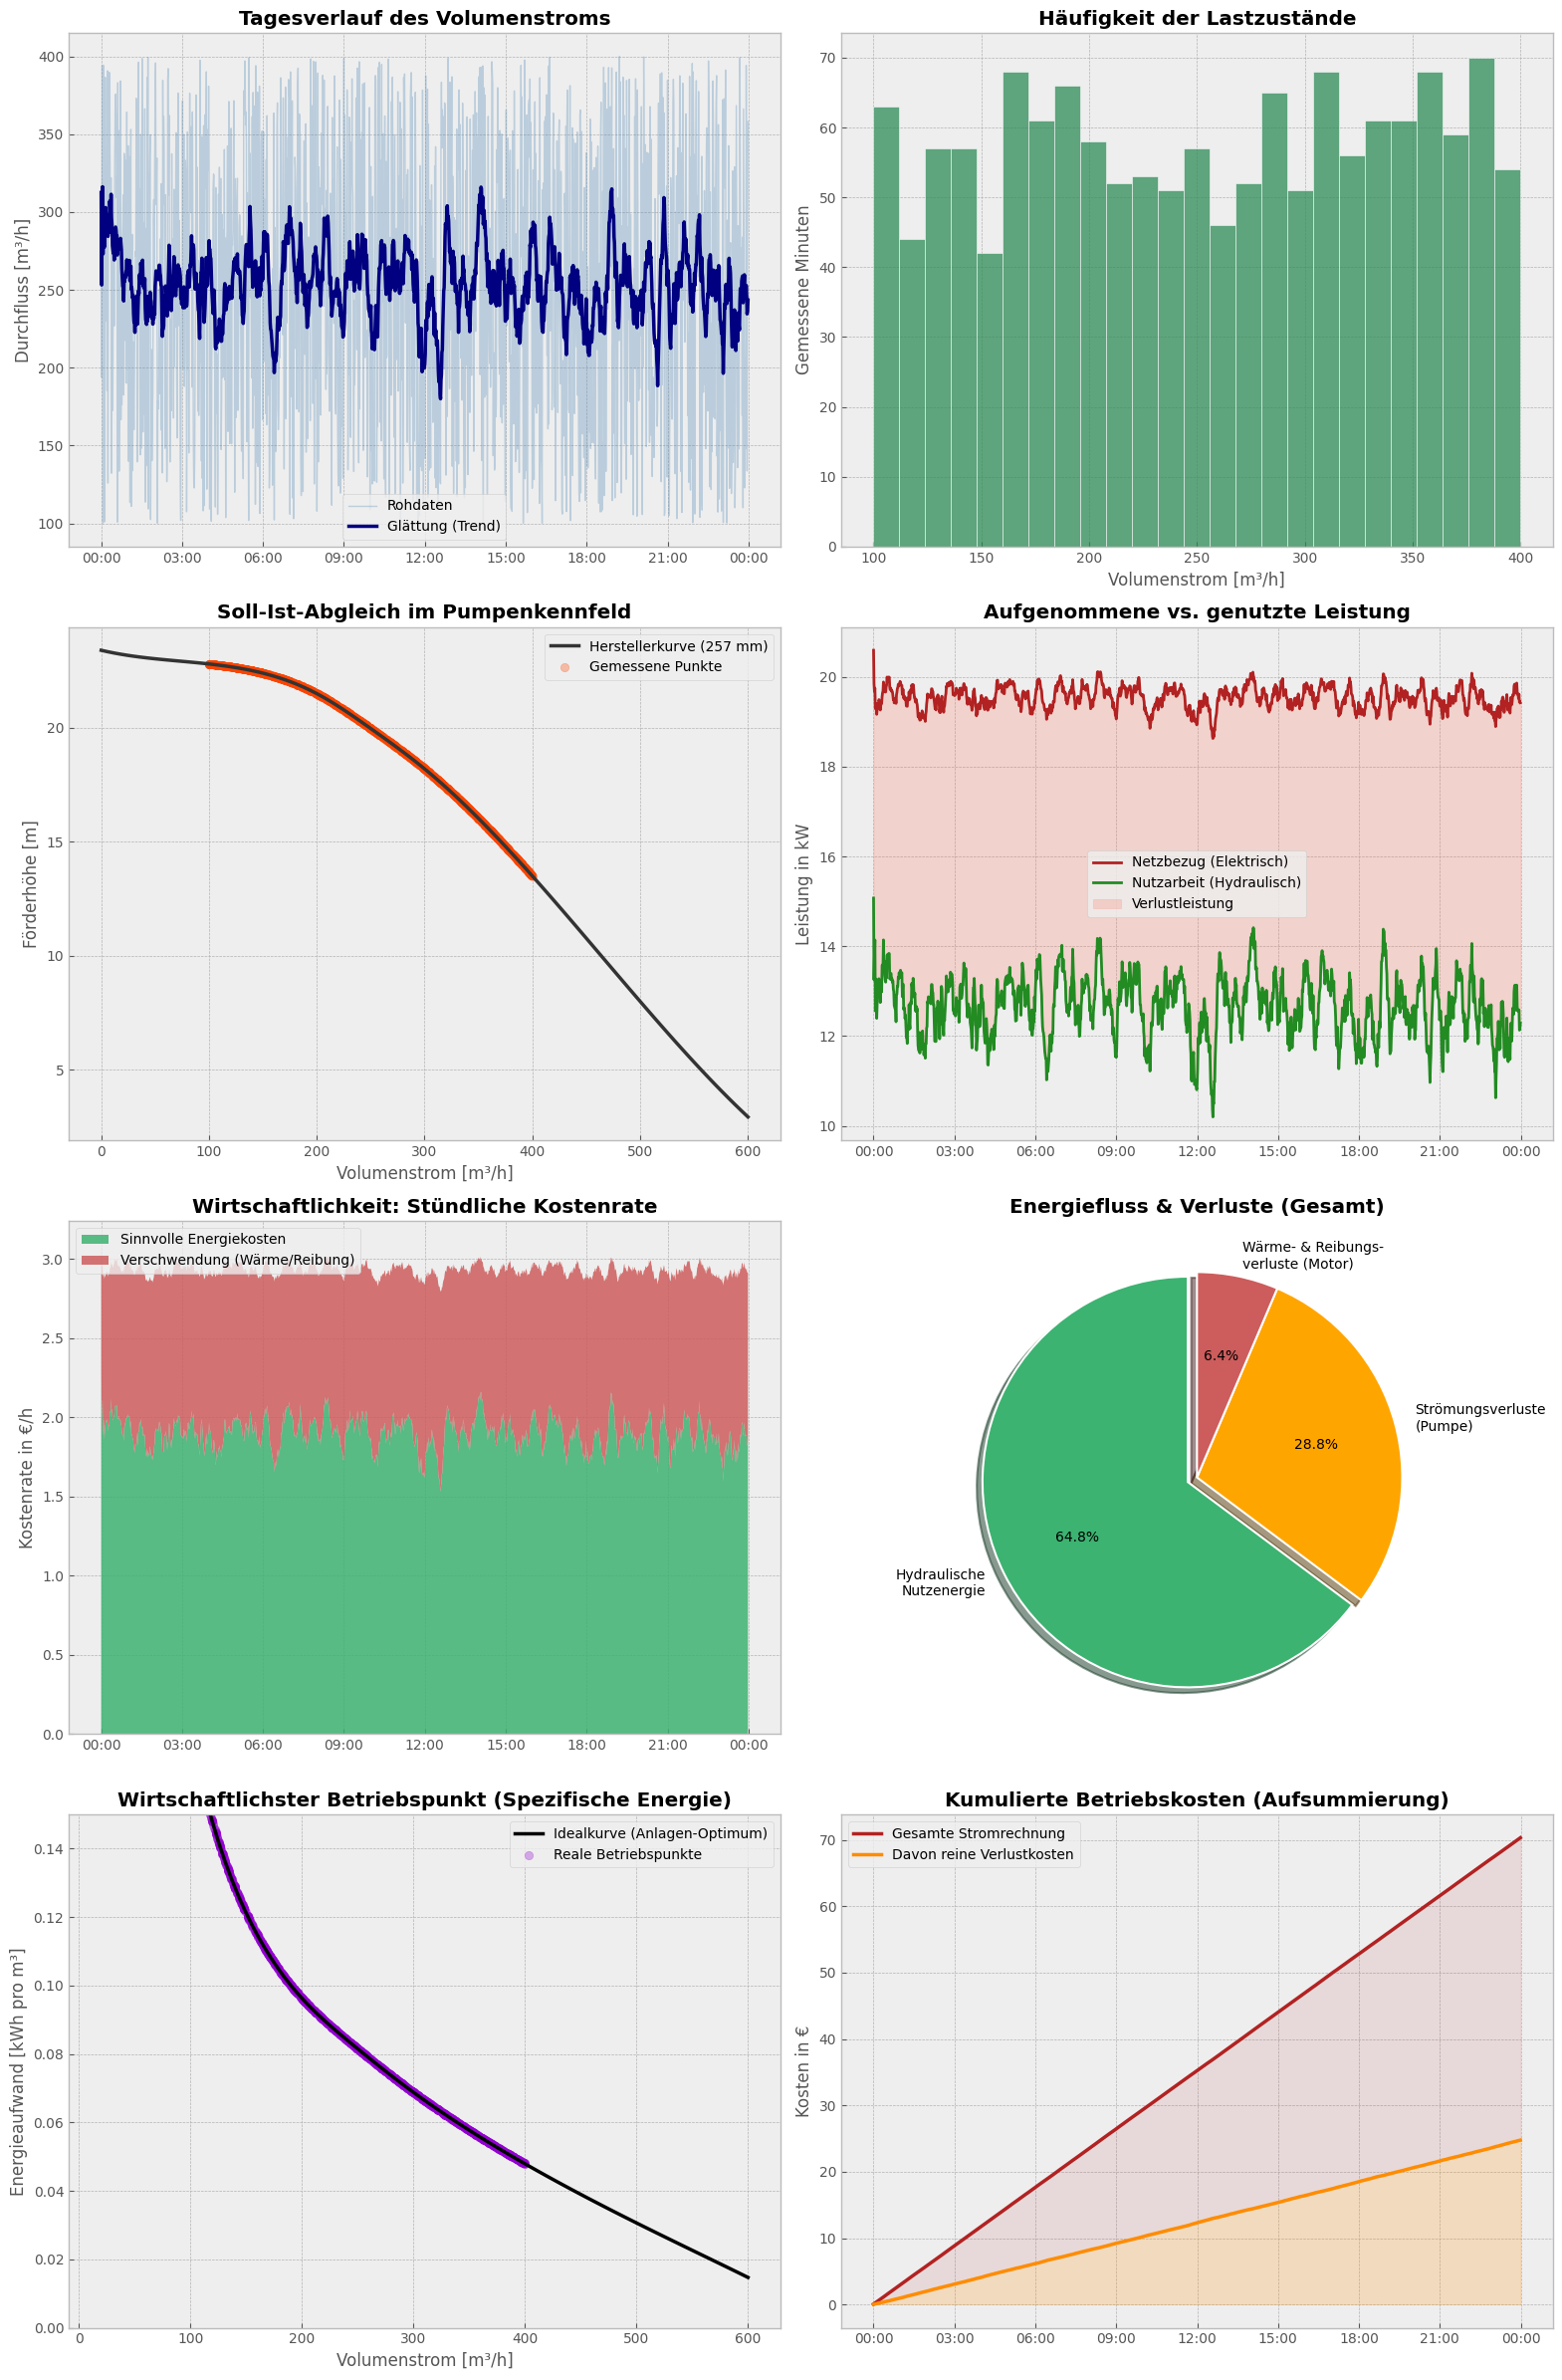

In [30]:
# ---------------------------------------------------------
# 5. Diagramme (Advanced Analytics & Individuelles Design)
# ---------------------------------------------------------
import warnings
warnings.filterwarnings("ignore") # Unterdrückt Warnungen bei Division durch Null

plt.style.use('bmh')
fig, axs = plt.subplots(4, 2, figsize=(16, 24)) # Jetzt 4 Reihen, 2 Spalten (8 Plots)

# --- Plot 1 bis 6 bleiben wie besprochen ---

# Plot 1: Durchfluss
axs[0, 0].plot(df['Timestamp'], df[col_flow], color='#4682B4', alpha=0.3, linewidth=1, label='Rohdaten')
axs[0, 0].plot(df['Timestamp'], df['Q_smoothed'], color='#000080', linewidth=2.5, label='Glättung (Trend)')
axs[0, 0].set_title('Tagesverlauf des Volumenstroms', fontweight='bold')
axs[0, 0].set_ylabel('Durchfluss [m³/h]')
axs[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[0, 0].legend()

# Plot 2: Histogramm
axs[0, 1].hist(df[col_flow], bins=25, color='#2E8B57', alpha=0.75, edgecolor='white')
axs[0, 1].set_title('Häufigkeit der Lastzustände', fontweight='bold')
axs[0, 1].set_xlabel('Volumenstrom [m³/h]')
axs[0, 1].set_ylabel('Gemessene Minuten')

# Plot 3: Kennfeld
Q_smooth_line = np.linspace(0, 600, 100)
axs[1, 0].plot(Q_smooth_line, f_H(Q_smooth_line), color='#333333', linewidth=2.5, label='Herstellerkurve (257 mm)')
axs[1, 0].scatter(df[col_flow], df['H_m'], color='#FF4500', alpha=0.3, label='Gemessene Punkte')
axs[1, 0].set_title('Soll-Ist-Abgleich im Pumpenkennfeld', fontweight='bold')
axs[1, 0].set_xlabel('Volumenstrom [m³/h]')
axs[1, 0].set_ylabel('Förderhöhe [m]')
axs[1, 0].legend()

# Plot 4: Leistungs-Verlauf
axs[1, 1].plot(df['Timestamp'], df['Power_grid_trend'], label='Netzbezug (Elektrisch)', color='#B22222', linewidth=2)
axs[1, 1].plot(df['Timestamp'], df['Power_hyd_trend'], label='Nutzarbeit (Hydraulisch)', color='#228B22', linewidth=2)
axs[1, 1].fill_between(df['Timestamp'], df['Power_hyd_trend'], df['Power_grid_trend'], color='#FF6347', alpha=0.2, label='Verlustleistung')
axs[1, 1].set_title('Aufgenommene vs. genutzte Leistung', fontweight='bold')
axs[1, 1].set_ylabel('Leistung in kW')
axs[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1, 1].legend()

# Plot 5: Kosten
axs[2, 0].stackplot(df['Timestamp'], df['Cost_hyd_trend'], df['Cost_loss_trend'],
                    labels=['Sinnvolle Energiekosten', 'Verschwendung (Wärme/Reibung)'],
                    colors=['#3CB371', '#CD5C5C'], alpha=0.85)
axs[2, 0].set_title('Wirtschaftlichkeit: Stündliche Kostenrate', fontweight='bold')
axs[2, 0].set_ylabel('Kostenrate in €/h')
axs[2, 0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2, 0].legend(loc='upper left')

# Plot 6: Energiebilanz (Kreisdiagramm)
energie_werte = [sum_E_hyd, sum_loss_pump, sum_loss_motor]
energie_labels = ['Hydraulische\nNutzenergie', 'Strömungsverluste\n(Pumpe)', 'Wärme- & Reibungs-\nverluste (Motor)']
energie_farben = ['#3CB371', '#FFA500', '#CD5C5C']
explode_stuecke = (0.05, 0, 0)
axs[2, 1].pie(energie_werte, labels=energie_labels, colors=energie_farben, explode=explode_stuecke,
              autopct='%1.1f%%', startangle=90, shadow=True,
              wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axs[2, 1].set_title('Energiefluss & Verluste (Gesamt)', fontweight='bold')

# =========================================================
# NEUE ADVANCED PLOTS (Reihe 4)
# =========================================================

# Plot 7: Spezifischer Energiebedarf (kWh / m³)
# Erstellung der theoretischen Idealkurve (Vermeidung von Division durch Null)
Q_sec = np.linspace(20, 600, 100)
P_hyd_sec = (rho * g * (Q_sec / 3600) * f_H(Q_sec)) / 1000
P_grid_sec = P_hyd_sec / (f_eta(Q_sec) * eta_motor)
SEC_ideal = P_grid_sec / Q_sec  # Spezifischer Energiebedarf in kWh/m³

# Berechnung der realen SEC-Werte aus den Messdaten
df['SEC_real'] = df['Power_grid_kW'] / df[col_flow].replace(0, np.nan)

axs[3, 0].plot(Q_sec, SEC_ideal, color='black', linewidth=2.5, label='Idealkurve (Anlagen-Optimum)')
axs[3, 0].scatter(df[col_flow], df['SEC_real'], color='#9400D3', alpha=0.3, label='Reale Betriebspunkte')
axs[3, 0].set_ylim(0, 0.15) # Zoom auf den relevanten Bereich
axs[3, 0].set_title('Wirtschaftlichster Betriebspunkt (Spezifische Energie)', fontweight='bold')
axs[3, 0].set_xlabel('Volumenstrom [m³/h]')
axs[3, 0].set_ylabel('Energieaufwand [kWh pro m³]')
axs[3, 0].legend()

# Plot 8: Kumulierte Kosten über den Tag ("Der Geld-Tacho")
# Aufsummieren der Stromkosten Minute für Minute
df['Cost_Total_Cum'] = (df['Power_grid_kW'] * delta_time * strom_tarif).cumsum()
df['Cost_Loss_Cum'] = (df['Loss_Total_kWh'] * strom_tarif).cumsum()

axs[3, 1].plot(df['Timestamp'], df['Cost_Total_Cum'], color='#B22222', linewidth=2.5, label='Gesamte Stromrechnung')
axs[3, 1].plot(df['Timestamp'], df['Cost_Loss_Cum'], color='#FF8C00', linewidth=2.5, label='Davon reine Verlustkosten')
axs[3, 1].fill_between(df['Timestamp'], 0, df['Cost_Loss_Cum'], color='#FF8C00', alpha=0.2)
axs[3, 1].fill_between(df['Timestamp'], df['Cost_Loss_Cum'], df['Cost_Total_Cum'], color='#B22222', alpha=0.1)

axs[3, 1].set_title('Kumulierte Betriebskosten (Aufsummierung)', fontweight='bold')
axs[3, 1].set_ylabel('Kosten in €')
axs[3, 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[3, 1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 6. Fazit und Interpretation der Ergebnisse
Die Auswertung der Messdaten lässt folgende Rückschlüsse auf das Betriebsverhalten der Anlage zu:

**1. Auslegung und Betriebsverhalten**
Im Messzeitraum arbeitet die Pumpe bei einem mittleren Volumenstrom von ca. 253 m³/h und einer Förderhöhe von rund 19,7 m. Damit trifft die Anlage im Durchschnitt den im Datenblatt geforderten Auslegungspunkt (250 m³/h). Der resultierende mittlere Pumpenwirkungsgrad von 69,6 % entspricht weitestgehend der Herstellervorgabe für diesen spezifischen Lastzustand (71,3 %).

**2. Systemverluste und Wirtschaftlichkeit**
Die Bilanzierung der Gesamtwirkungsgradkette zeigt, dass etwa 35 % der elektrischen Eingangsleistung in Form von Motor- und Hydraulikverlusten abgeführt werden. Bezogen auf die vorliegende Tagesmessung resultiert daraus ein Verlustkostenanteil von rund 65 € pro Tag. Unter der Annahme eines kontinuierlichen Dauerbetriebs summiert sich diese systembedingte Ineffizienz auf über 23.000 € pro Betriebsjahr.

**3. Systemeffizienz**
Eine Analyse des spezifischen Energiebedarfs (Plot 7) verdeutlicht, dass das  Optimum der Pumpe erst im Bereich von 350 bis 400 m³/h erreicht wird. Mit einem durchschnittlichen Betrieb bei 253 m³/h operiert die Anlage lediglich bei etwa 63 % ihres effizientesten Punkts.